In [1]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
from collections import Counter

import glob


sample = "/gv0/Users/achihwan/phase2/cmssw_16/run3_wtau_wprime/w/WtoTauNu_M200/90000/1e9e2842-2645-4e2c-8a75-3e7e8107229f.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()




In [43]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
from collections import Counter

vector.register_awkward()
plt.style.use(hep.style.CMS)

# --- 파일 목록 ---
sample_dir = "/gv0/Users/achihwan/phase2/cmssw_16/run3_wtau_wprime/wprime/"
file_list = glob.glob(os.path.join(sample_dir, "**/*.root"), recursive=True)
print(f"총 {len(file_list)}개 파일 발견")

# --- binning 설정 ---
bin1 = np.arange(0, 200, 10)
bin2 = np.arange(200, 450, 50)
bins = np.concatenate([bin1, bin2])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# --- 누적 histogram ---
denom_counts = np.zeros(len(bins) - 1, dtype=np.float64)
numer_counts = np.zeros(len(bins) - 1, dtype=np.float64)

# --- 파일 루프 ---
for fpath in tqdm(file_list, desc="Processing files"):
    try:
        f = uproot.open(fpath)
        events = f["Events"]

        hlt          = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()
        genvistau_pt = events["GenVisTau_pt"].array()

        # hlt를 genvistau 차원에 맞게 broadcast
        hlt_broadcast = ak.broadcast_arrays(genvistau_pt, hlt)[1]

        pt_all   = ak.to_numpy(ak.flatten(genvistau_pt))
        hlt_flat = ak.to_numpy(ak.flatten(hlt_broadcast))

        d, _ = np.histogram(pt_all,               bins=bins)
        n, _ = np.histogram(pt_all[hlt_flat == 1], bins=bins)

        denom_counts += d
        numer_counts += n

    except Exception as e:
        print(f"[SKIP] {fpath}: {e}")

# --- efficiency 계산 ---
efficiency = np.where(denom_counts > 0, numer_counts / denom_counts, 0)
eff_err = np.where(
    denom_counts > 0,
    np.sqrt(efficiency * (1 - efficiency) / denom_counts),
    0
)
print(len(denom_counts), len(numer_counts), len(efficiency), len(eff_err))


총 11개 파일 발견


Processing files: 100%|██████████| 11/11 [00:21<00:00,  1.95s/it]

24 24 24 24



/tmp/ipykernel_1298507/3987660084.py:64: RuntimeWarning: invalid value encountered in divide
  efficiency = np.where(denom_counts > 0, numer_counts / denom_counts, 0)
/tmp/ipykernel_1298507/3987660084.py:67: RuntimeWarning: invalid value encountered in divide
  np.sqrt(efficiency * (1 - efficiency) / denom_counts),


In [44]:
print(denom_counts)
print(numer_counts)
new_numer = numer_counts[-6:]
new_denom = denom_counts[-6:]

print(np.sum(numer_counts))
print(np.sum(denom_counts))
print(np.sum(numer_counts)/np.sum(denom_counts))
print(np.sum(new_numer)/np.sum(new_denom))



[   0. 1063. 1512. 1742. 1989. 2067. 2100. 2199. 2184. 2177. 2135. 2058.
 1897. 1759. 1550. 1400. 1137.  984.  699.  434.  519.   73.   20.   13.]
[  0.   2.   1.   0.   1.   0.   0.   2.   1.   1.   1.   1.   4.   7.
  15.  15.  55. 101. 211. 208. 319.  59.  17.  10.]
1031.0
31711.0
0.032512377408470246
0.46871444823663255


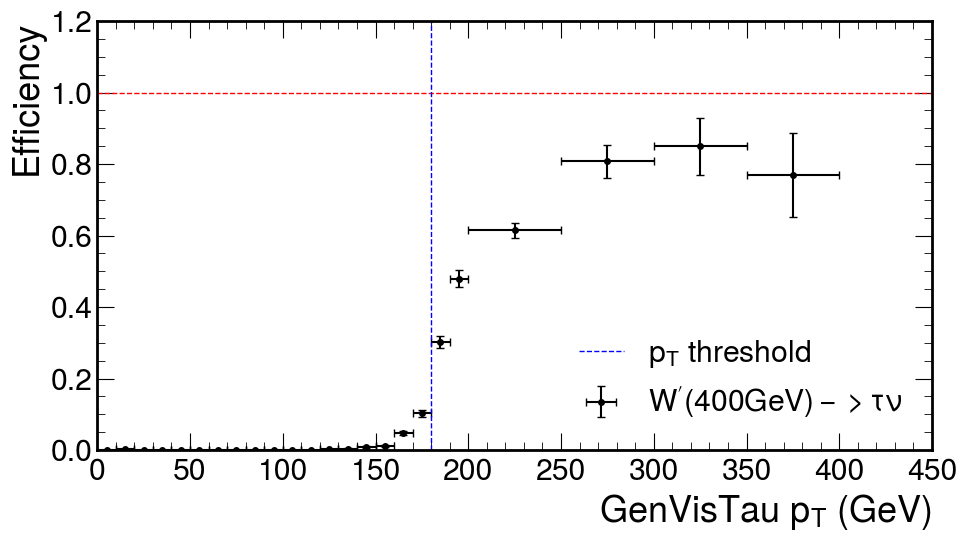

In [24]:
xerr = 0.5 * (bins[1:] - bins[:-1])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    bin_centers, efficiency,
    xerr=xerr, yerr=eff_err,
    fmt='o', color='black', markersize=4, capsize=3,
    label="$W'(400GeV) -> \\tau\\nu$"
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1)
ax.axvline(180, color='blue', linestyle='--', linewidth=1, label='$p_T$ threshold')
ax.set_xlabel(r'GenVisTau $p_T$ (GeV)')
ax.set_ylabel('Efficiency')
ax.set_ylim(0, 1.2)
ax.set_xlim(0, 450)
ax.legend()
plt.tight_layout()
plt.savefig("turnon_combined.png", dpi=150)
plt.show()

In [40]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
from collections import Counter

vector.register_awkward()
plt.style.use(hep.style.CMS)

# --- 파일 목록 ---
sample_dir = "/gv0/Users/achihwan/phase2/cmssw_16/run3_wtau_wprime/w/WtoTauNu_M200/"
file_list = glob.glob(os.path.join(sample_dir, "**/*.root"), recursive=True)
print(f"총 {len(file_list)}개 파일 발견")

# --- binning 설정 ---
bin1 = np.arange(0, 200, 10)
bin2 = np.arange(200, 450, 50)
bins = np.concatenate([bin1, bin2])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# --- 누적 histogram ---
denom_counts = np.zeros(len(bins) - 1, dtype=np.float64)
numer_counts = np.zeros(len(bins) - 1, dtype=np.float64)

# --- 파일 루프 ---
for fpath in tqdm(file_list, desc="Processing files"):
    try:
        f = uproot.open(fpath)
        events = f["Events"]

        hlt          = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()
        genvistau_pt = events["GenVisTau_pt"].array()

        # hlt를 genvistau 차원에 맞게 broadcast
        hlt_broadcast = ak.broadcast_arrays(genvistau_pt, hlt)[1]

        pt_all   = ak.to_numpy(ak.flatten(genvistau_pt))
        hlt_flat = ak.to_numpy(ak.flatten(hlt_broadcast))

        d, _ = np.histogram(pt_all,               bins=bins)
        n, _ = np.histogram(pt_all[hlt_flat == 1], bins=bins)

        denom_counts += d
        numer_counts += n

    except Exception as e:
        print(f"[SKIP] {fpath}: {e}")

# --- efficiency 계산 ---
efficiency = np.where(denom_counts > 0, numer_counts / denom_counts, 0)
eff_err = np.where(
    denom_counts > 0,
    np.sqrt(efficiency * (1 - efficiency) / denom_counts),
    0
)

print(np.sum(denom_counts))
print(np.sum(numer_counts))

총 127개 파일 발견


Processing files:   0%|          | 0/127 [00:00<?, ?it/s]

Processing files: 100%|██████████| 127/127 [04:17<00:00,  2.03s/it]

8736767.0
95842.0



/tmp/ipykernel_1298507/830090070.py:64: RuntimeWarning: invalid value encountered in divide
  efficiency = np.where(denom_counts > 0, numer_counts / denom_counts, 0)
/tmp/ipykernel_1298507/830090070.py:67: RuntimeWarning: invalid value encountered in divide
  np.sqrt(efficiency * (1 - efficiency) / denom_counts),


In [42]:
print(denom_counts)
print(numer_counts)
new_numer = numer_counts[-6:]
new_denom = denom_counts[-6:]

print(np.sum(numer_counts))
print(np.sum(denom_counts))
print(np.sum(numer_counts)/np.sum(denom_counts))
print(np.sum(new_numer)/np.sum(new_denom))



[      0.  824803.  995080. 1015882.  987485.  923663.  830732.  732452.
  616549.  491484.  355594.  247117.  172700.  126251.   92036.   69098.
   52010.   40038.   31506.   24600.   66063.   25275.   11058.    5291.]
[    0.   212.   230.   227.   216.   205.   192.   195.   169.   159.
   157.   191.   201.   296.   407.   788.  1561.  3359.  8621. 10614.
 38081. 17298.  8299.  4164.]
95842.0
8736767.0
0.010969961771900292
0.5316283357652647


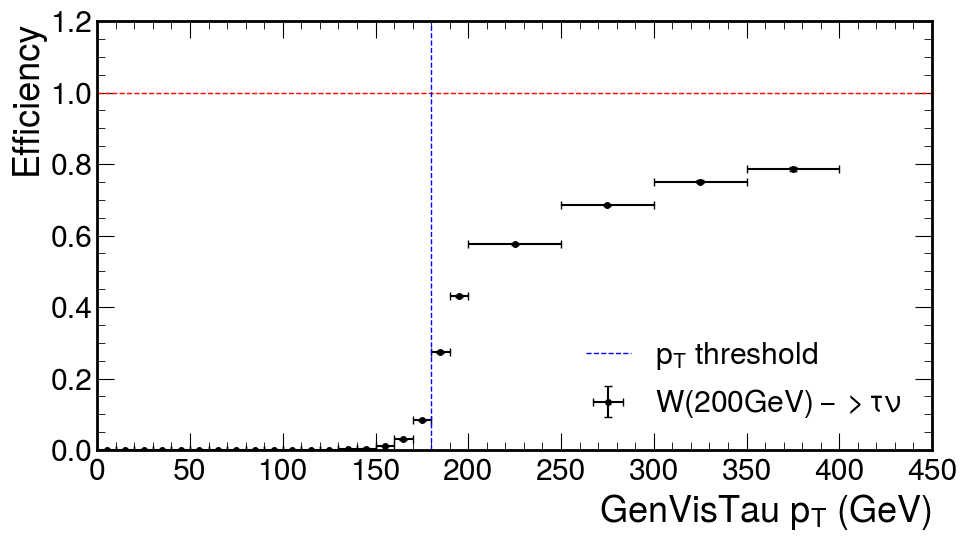

In [28]:
xerr = 0.5 * (bins[1:] - bins[:-1])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    bin_centers, efficiency,
    xerr=xerr, yerr=eff_err,
    fmt='o', color='black', markersize=4, capsize=3,
    label="$W(200GeV) -> \\tau\\nu$"
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1)
ax.axvline(180, color='blue', linestyle='--', linewidth=1, label='$p_T$ threshold')
ax.set_xlabel(r'GenVisTau $p_T$ (GeV)')
ax.set_ylabel('Efficiency')
ax.set_ylim(0, 1.2)
ax.set_xlim(0, 450)
ax.legend()
plt.tight_layout()
plt.savefig("turnon_combined.png", dpi=150)
plt.show()